Imports


In [1]:
# Import libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Import deep learning tools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import warnings

# Ignore warnings and set random seed
warnings.filterwarnings('ignore')
tf.random.set_seed(101)

Data Loading

In [2]:
# Load the data
df = pd.read_csv('data/titanic.csv')

# Look at the first 5 rows
print("First 5 rows:")
print(df.head())

# Look at the size of the data
print("\nData shape (rows, columns):")
print(df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check how many people survived (percentage)
print("\nSurvived percentage:")
print(df['Survived'].value_counts(normalize=True).round(2))

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

Preprocessing

In [3]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop columns we don't need
df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])

# Change text to numbers
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

# Split data into X (features) and y (target)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101, stratify=y
)

# Scale the data so all numbers are in a similar range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ML Models

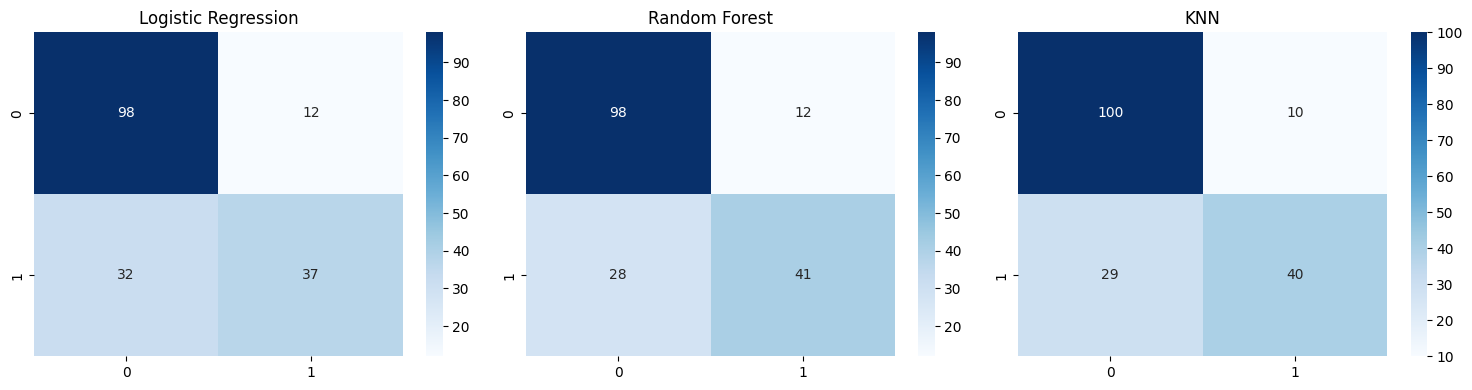


Machine Learning Results:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression      0.75       0.76    0.54      0.63
1        Random Forest      0.78       0.77    0.59      0.67
2                  KNN      0.78       0.80    0.58      0.67


In [4]:
# Make a list of models to try
models = {
    'Logistic Regression': LogisticRegression(random_state=101),
    'Random Forest': RandomForestClassifier(random_state=101),
    'KNN': KNeighborsClassifier()
}

results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train and test each model
for i, (name, model) in enumerate(models.items()):
    # Train model
    model.fit(X_train_scaled, y_train)

    # Predict
    predictions = model.predict(X_test_scaled)

    # Calculate scores
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    # Save results
    results.append([name, acc, prec, rec, f1])

    # Draw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

# Print the results in a table
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)
print('\nMachine Learning Results:')
print(results_df.round(2))

Deep Learning

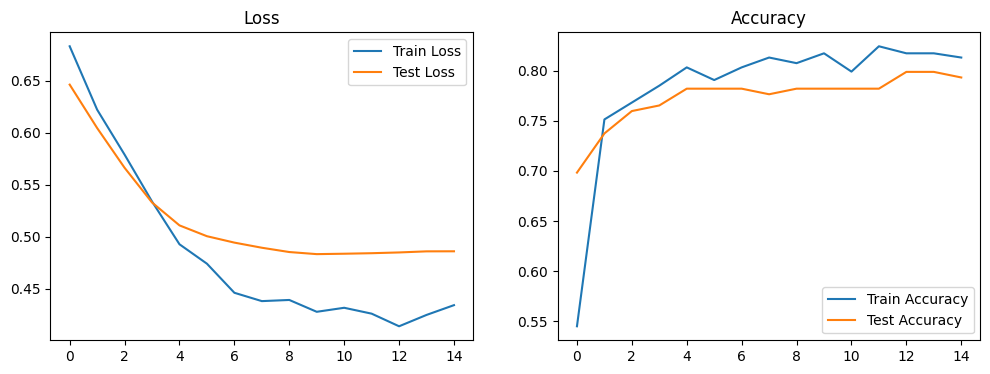

In [5]:
# Build a simple Neural Network
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Stop overfitting
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for 0 or 1 output
])

# Compile the model
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=15,
    verbose=0
)

# Plot training and validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Test Loss')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Test Accuracy')
ax2.set_title('Accuracy')
ax2.legend()

plt.show()

Final Results

In [6]:
# Get neural network predictions
nn_probs = nn_model.predict(X_test_scaled, verbose=0)
nn_preds = (nn_probs > 0.5).astype(int) # Change to 0 or 1

# Calculate scores for neural network
nn_results = [
    'Neural Network',
    accuracy_score(y_test, nn_preds),
    precision_score(y_test, nn_preds),
    recall_score(y_test, nn_preds),
    f1_score(y_test, nn_preds)
]

# Add to the other results
final_df = pd.concat(
    [results_df, pd.DataFrame([nn_results], columns=results_df.columns)],
    ignore_index=True
)

print('\nFinal Results Table:')
print(final_df.round(2))

print('\nConclusion:')
print('Random Forest is the best model here because it has the highest F1-Score.')


Final Results Table:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression      0.75       0.76    0.54      0.63
1        Random Forest      0.78       0.77    0.59      0.67
2                  KNN      0.78       0.80    0.58      0.67
3       Neural Network      0.79       0.85    0.57      0.68

Conclusion:
Random Forest is the best model here because it has the highest F1-Score.
